##IPL Auction Intelligence: Identifying Reliable Players

IPL franchises invest heavily in player auctions, but the most expensive player is not always the most valuable. To make smarter auction decisions, we need to identify players who consistently contribute to their team's success.

##Key Qualities of a Valuable Player

Consistency – Performs well across multiple seasons.

Match Impact – Contributes to winning matches.

Pressure Performance – Delivers in crucial matches such as playoffs and finals.

Reliability – Maintains performance over a long period.

Efficiency – Makes the most of the opportunities available.


###This analysis aims to identify:
*The most reliable batters.

*The most reliable bowlers.

*Players who perform under pressure.

*Players who provide the best return on auction investment.


In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Loading Dataset
ipl_dataset = pd.read_csv(
    "C:\\Users\\Dilawar Singh\\Downloads\\archive (1)\\IPL.csv",
    low_memory=False
)

In [5]:
ipl_dataset.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


## Data Loading

The IPL ball-by-ball dataset is loaded using Pandas. The dataset contains detailed information about every delivery bowled in IPL history, including batting performance, bowling performance, match outcomes, venues, and player statistics.

This dataset will serve as the foundation for evaluating player reliability and identifying valuable auction investments.

In [6]:
print("Dataset Shape:", ipl_dataset.shape)
print("Number of Rows:", ipl_dataset.shape[0])
print("Number of Columns:", ipl_dataset.shape[1])

Dataset Shape: (283678, 65)
Number of Rows: 283678
Number of Columns: 65


## Dataset Dimensions

Understanding the size of the dataset is the first step in any analysis.
The number of rows represents the total ball-by-ball records, while the number of columns represents the available features that can be used for analysis.

In [7]:
print("Columns in Dataset:\n")

for col in ipl_dataset.columns:
    print(col)

Columns in Dataset:

Unnamed: 0
match_id
date
match_type
event_name
innings
batting_team
bowling_team
over
ball
ball_no
batter
bat_pos
runs_batter
balls_faced
bowler
valid_ball
runs_extras
runs_total
runs_bowler
runs_not_boundary
extra_type
non_striker
non_striker_pos
wicket_kind
player_out
fielders
runs_target
review_batter
team_reviewed
review_decision
umpire
umpires_call
player_of_match
match_won_by
win_outcome
toss_winner
toss_decision
venue
city
day
month
year
season
gender
team_type
superover_winner
result_type
method
balls_per_over
overs
event_match_no
stage
match_number
team_runs
team_balls
team_wicket
new_batter
power_surge_start
batter_runs
batter_balls
bowler_wicket
batting_partners
next_batter
striker_out


In [8]:
ipl_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 65 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  object 
 3   match_type         283678 non-null  object 
 4   event_name         283678 non-null  object 
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  object 
 7   bowling_team       283678 non-null  object 
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  object 
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  object 
 16  va

In [9]:
ipl_dataset.dtypes

Unnamed: 0           int64
match_id             int64
date                object
match_type          object
event_name          object
                     ...  
batter_balls         int64
bowler_wicket        int64
batting_partners    object
next_batter         object
striker_out           bool
Length: 65, dtype: object

## Data Types

Examining data types helps identify whether each column contains numerical, categorical, or date-related information. This step is important because incorrect data types can affect calculations and visualizations later in the analysis.

In [11]:
#Summary
print(f"Total Records: {ipl_dataset.shape[0]}")
print(f"Total Features: {ipl_dataset.shape[1]}")

Total Records: 283678
Total Features: 65


In [13]:
#Count Missing Values
missing_values = ipl_dataset.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

power_surge_start    283678
review_batter        282771
team_reviewed        282771
review_decision      282771
umpire               282771
method               279788
superover_winner     279782
result_type          278954
fielders             273433
new_batter           270085
next_batter          270085
wicket_kind          269572
player_out           269572
extra_type           268185
runs_target          147168
win_outcome            4724
dtype: int64

In [14]:
#Missing value percentage
missing_percentage = (
    ipl_dataset.isnull().sum() /
    len(ipl_dataset)
) * 100

missing_df = pd.DataFrame({
    'Missing Values': ipl_dataset.isnull().sum(),
    'Percentage': missing_percentage
})

missing_df = missing_df[
    missing_df['Missing Values'] > 0
].sort_values(
    by='Percentage',
    ascending=False
)

missing_df

,Missing Values,Percentage
power_surge_start,283678,100.000000
review_batter,282771,99.680271
team_reviewed,282771,99.680271
review_decision,282771,99.680271
umpire,282771,99.680271
method,279788,98.628727
superover_winner,279782,98.626612
result_type,278954,98.334732
fielders,273433,96.388511
new_batter,270085,95.208300


## Missing Value Analysis

Missing values can affect the quality of analysis and lead to misleading conclusions.

The missing value analysis helps identify:

- Columns that are largely incomplete.
- Features that may not be useful for player evaluation.
- Data quality issues that need to be addressed before analysis.

Columns with extremely high missing percentages may be removed if they do not contribute significantly to the business objective.

In [15]:
# -----------------------------
# Remove columns with extremely high missing values
# and low relevance to player, team, and venue analysis
# -----------------------------

drop_cols = [
    'power_surge_start',
    'review_batter',
    'team_reviewed',
    'review_decision',
    'umpire',
    'method',
    'superover_winner'
]

ipl_dataset.drop(columns=drop_cols, inplace=True)

# Verify removal
print("Updated Dataset Shape:", ipl_dataset.shape)
print("\nRemaining Columns:", len(ipl_dataset.columns))

Updated Dataset Shape: (283678, 58)

Remaining Columns: 58


## Missing Value Treatment

Several columns contained more than 95% missing values and were not directly relevant to player evaluation, team performance, or venue analysis. These columns were removed to improve data quality and reduce noise.

The following columns were retained despite having missing values:

- wicket_kind
- player_out
- fielders
- extra_type
- result_type
- runs_target

Missing values in these columns are expected because they correspond to specific match events that do not occur on every ball.

In [16]:
# Check duplicate records
print("Duplicate Rows:", ipl_dataset.duplicated().sum())

Duplicate Rows: 0


## Duplicate Record Analysis

Duplicate records can lead to inaccurate calculations and biased insights. Therefore, the dataset was checked for duplicate entries before analysis.

The dataset contained no duplicate rows, indicating good data quality and ensuring that each ball-by-ball event is uniquely recorded.

In [18]:
sorted(ipl_dataset['batting_team'].dropna().unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Delhi Daredevils',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

In [30]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore'
}

team_cols = [
    'batting_team',
    'bowling_team',
    'toss_winner',
    'match_won_by'
]

ipl_dataset[team_cols] = (
    ipl_dataset[team_cols]
    .replace(team_mapping)
)

In [31]:
'Unnamed: 0' in ipl_dataset.columns

False

In [32]:
#Convert Date Column
ipl_dataset['date'] = pd.to_datetime(
    ipl_dataset['date'],
    errors='coerce'
)

In [33]:
ipl_dataset['date'].dtype

dtype('<M8[ns]')

In [34]:
numeric_cols = [
    'over',
    'ball',
    'runs_batter',
    'runs_extras',
    'runs_total',
    'runs_bowler',
    'team_runs',
    'team_balls',
    'team_wicket',
    'balls_faced',
    'bat_pos'
]

for col in numeric_cols:
    if col in ipl_dataset.columns:
        ipl_dataset[col] = pd.to_numeric(
            ipl_dataset[col],
            errors='coerce'
        )

## Data Type Standardization

To ensure accurate analysis, important columns were converted to appropriate data types. The date column was converted to datetime format, while numerical features were validated and converted where necessary.

This step improves consistency and enables time-based and statistical analyses.

In [35]:
matches = ipl_dataset.drop_duplicates(
    subset='match_id'
).copy()

In [36]:
sorted(ipl_dataset['batting_team'].dropna().unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Sunrisers Hyderabad']

In [37]:
sorted(ipl_dataset['bowling_team'].dropna().unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Sunrisers Hyderabad']

In [38]:
ipl_dataset['batting_team'].nunique()

15

In [39]:
ipl_dataset['batting_team'].value_counts()

batting_team
Mumbai Indians                 33892
Royal Challengers Bangalore    32308
Punjab Kings                   31977
Delhi Capitals                 31886
Kolkata Knight Riders          31398
Chennai Super Kings            31027
Rajasthan Royals               28430
Sunrisers Hyderabad            24078
Deccan Chargers                 9034
Gujarat Titans                  7827
Lucknow Super Giants            7750
Pune Warriors                   5443
Gujarat Lions                   3566
Rising Pune Supergiants         3480
Kochi Tuskers Kerala            1582
Name: count, dtype: int64

In [40]:
matches = ipl_dataset.drop_duplicates(
    subset='match_id'
).copy()

In [41]:
total_matches = matches['match_id'].nunique()

total_players = pd.concat([
    ipl_dataset['batter'],
    ipl_dataset['bowler']
]).nunique()

total_teams = pd.concat([
    matches['batting_team'],
    matches['bowling_team']
]).nunique()

total_venues = matches['venue'].nunique()

total_seasons = matches['season'].nunique()

In [42]:
print("Total Matches :", total_matches)
print("Total Players :", total_players)
print("Total Teams   :", total_teams)
print("Total Venues  :", total_venues)
print("Total Seasons :", total_seasons)

Total Matches : 1193
Total Players : 788
Total Teams   : 15
Total Venues  : 59
Total Seasons : 19


## Dataset Overview

Before evaluating players and teams, it is important to understand the scale of the dataset.

The IPL dataset contains ball-by-ball information across multiple seasons, teams, venues, and players. This provides a strong foundation for identifying reliable players and making data-driven auction decisions.

In [43]:
#Team Analysis 1: Most Successful Teams
team_wins = (
    matches['match_won_by']
    .value_counts()
    .head(10)
)

team_wins

match_won_by
Mumbai Indians                 152
Chennai Super Kings            144
Royal Challengers Bangalore    136
Kolkata Knight Riders          135
Punjab Kings                   123
Delhi Capitals                 120
Rajasthan Royals               118
Sunrisers Hyderabad             95
Gujarat Titans                  39
Lucknow Super Giants            32
Name: count, dtype: int64

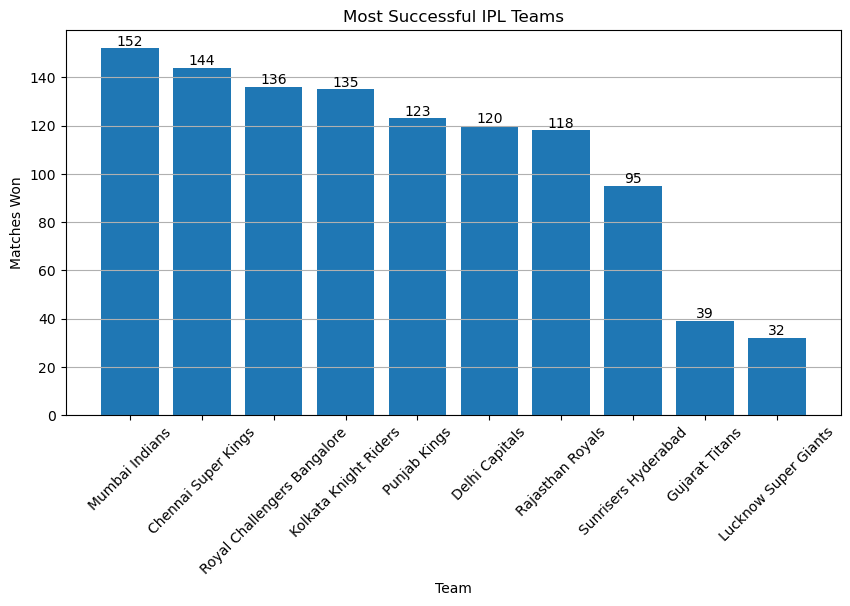

In [44]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    team_wins.index,
    team_wins.values
)

plt.title("Most Successful IPL Teams")
plt.xlabel("Team")
plt.ylabel("Matches Won")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.bar_label(bars)

plt.show()

## Most Successful Teams

The number of matches won provides a direct measure of a team's historical success.

Teams with consistently high win counts demonstrate strong squad composition, effective leadership, and long-term performance across seasons.

In [45]:
#Mumbai Indians and Chennai Super Kings have been the most successful franchises in IPL history, 
# suggesting that long-term squad stability and smart player investments contribute significantly
# to sustained success.

Team Analysis 2: Win Percentage

In [48]:
#Step 1: Matches Played
matches_played = pd.concat([
    matches['batting_team'],
    matches['bowling_team']
]).value_counts()

In [54]:
#Step 2: Matches Won
matches_won = (
    matches['match_won_by']
    .replace('Unknown', np.nan)
    .dropna()
    .value_counts()
)

In [55]:
#Step 3: Create DataFrame
team_stats = pd.DataFrame({
    'Matches_Played': matches_played,
    'Matches_Won': matches_won
}).fillna(0)

In [56]:
#Step 4: Win Percentage
team_stats['Win_Percentage'] = (
    team_stats['Matches_Won']
    /
    team_stats['Matches_Played']
) * 100


In [57]:
#Step 5: Sort
team_stats = team_stats.sort_values(
    'Win_Percentage',
    ascending=False
)
team_stats.head(10)

,Matches_Played,Matches_Won,Win_Percentage
Gujarat Titans,64,39,60.937500
Chennai Super Kings,257,144,56.031128
Mumbai Indians,282,152,53.900709
Lucknow Super Giants,63,32,50.793651
Kolkata Knight Riders,269,135,50.185874
Rising Pune Supergiants,30,15,50.000000
Royal Challengers Bangalore,275,136,49.454545
Rajasthan Royals,240,118,49.166667
Sunrisers Hyderabad,201,95,47.263682
Punjab Kings,269,123,45.724907


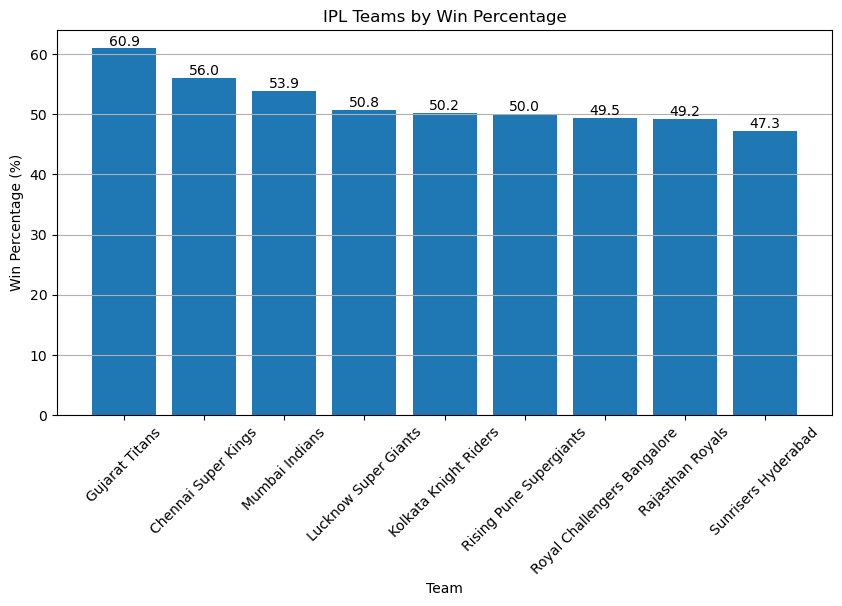

In [53]:
top_win_pct = team_stats.head(10)

plt.figure(figsize=(10,5))

bars = plt.bar(
    top_win_pct.index,
    top_win_pct['Win_Percentage']
)

plt.title("IPL Teams by Win Percentage")
plt.xlabel("Team")
plt.ylabel("Win Percentage (%)")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.bar_label(bars, fmt='%.1f')

plt.show()

Gujarat Titans have achieved the highest win percentage despite being one of the newest franchises, indicating exceptional team construction and strategy.


CSK combines longevity with a high win percentage, making them the benchmark for sustained IPL success.

Mumbai Indians have the highest number of wins while maintaining an excellent win rate, highlighting the value of retaining a strong core squad.

Despite having star players and a high number of wins, RCB's win percentage remains below 50%, suggesting that star power alone does not guarantee long-term success.

## Team Analysis 3: Does Winning the Toss Matter?

In [60]:
#Step 1: Calculate Toss Impact
toss_advantage = (
    matches['toss_winner']
    ==
    matches['match_won_by']
)

toss_win_percentage = (
    toss_advantage.mean()
) * 100

print(f"Toss Winner Won Match: {toss_win_percentage:.2f}%")

Toss Winner Won Match: 50.80%


In [61]:
#Step 2: Count Wins vs Losses After Toss
toss_results = toss_advantage.value_counts()

toss_results

True     606
False    587
Name: count, dtype: int64

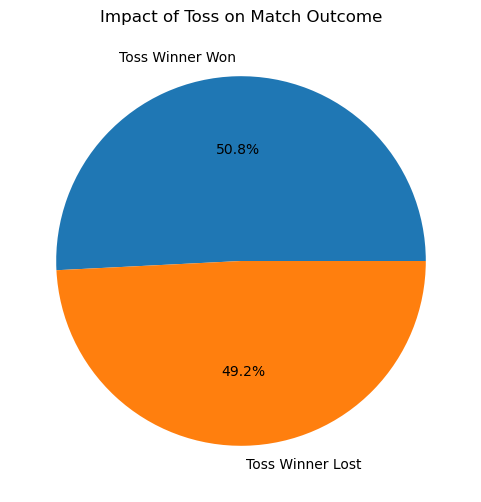

In [62]:
#Step 3: Visualize
plt.figure(figsize=(6,6))

plt.pie(
    toss_results,
    labels=['Toss Winner Won', 'Toss Winner Lost'],
    autopct='%1.1f%%'
)

plt.title('Impact of Toss on Match Outcome')

plt.show()

## Toss Impact Analysis

Winning the toss is often considered a major advantage in T20 cricket. This analysis evaluates whether the team winning the toss also wins the match.

By comparing toss winners with match winners, we can determine the actual influence of the toss on match outcomes.

## Venue Analysis 1: Most Frequently Used Venues

In [63]:
top_venues = matches['venue'].value_counts().head(10)

top_venues

venue
Eden Gardens                                 77
Wankhede Stadium                             73
M Chinnaswamy Stadium                        65
Feroz Shah Kotla                             60
Wankhede Stadium, Mumbai                     55
Rajiv Gandhi International Stadium, Uppal    49
MA Chidambaram Stadium, Chepauk              48
Sawai Mansingh Stadium                       47
Dubai International Cricket Stadium          46
MA Chidambaram Stadium, Chepauk, Chennai     37
Name: count, dtype: int64

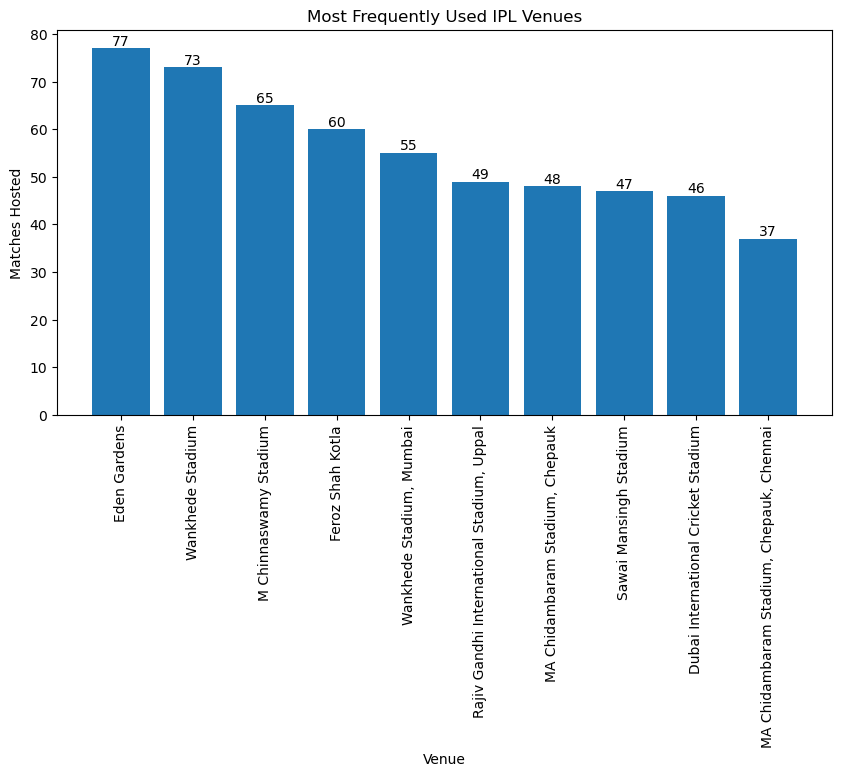

In [64]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    top_venues.index,
    top_venues.values
)

plt.title("Most Frequently Used IPL Venues")
plt.xlabel("Venue")
plt.ylabel("Matches Hosted")

plt.xticks(rotation=90)

plt.bar_label(bars)

plt.show()

## Venue Analysis 2: Highest Scoring Venues

In [65]:
matches[['venue','team_runs']].head()

,venue,team_runs
0,M Chinnaswamy Stadium,1
225,"Punjab Cricket Association Stadium, Mohali",0
473,Feroz Shah Kotla,0
692,Wankhede Stadium,0
938,Eden Gardens,1


In [66]:
# Issue 1: team_runs is not usable
# Issue 2: Venue Names Need Cleaning
venue_mapping = {
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium, Chepauk'
}

ipl_dataset['venue'] = (
    ipl_dataset['venue']
    .replace(venue_mapping)
)

matches['venue'] = (
    matches['venue']
    .replace(venue_mapping)
)

## Batter Analysis 1: Top Run Scorers

In [67]:
top_runs = (
    ipl_dataset.groupby('batter')['runs_batter']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_runs

batter
V Kohli           8899
RG Sharma         7185
S Dhawan          6769
DA Warner         6567
SK Raina          5536
MS Dhoni          5439
KL Rahul          5346
AM Rahane         5184
AB de Villiers    5181
CH Gayle          4997
Name: runs_batter, dtype: int64

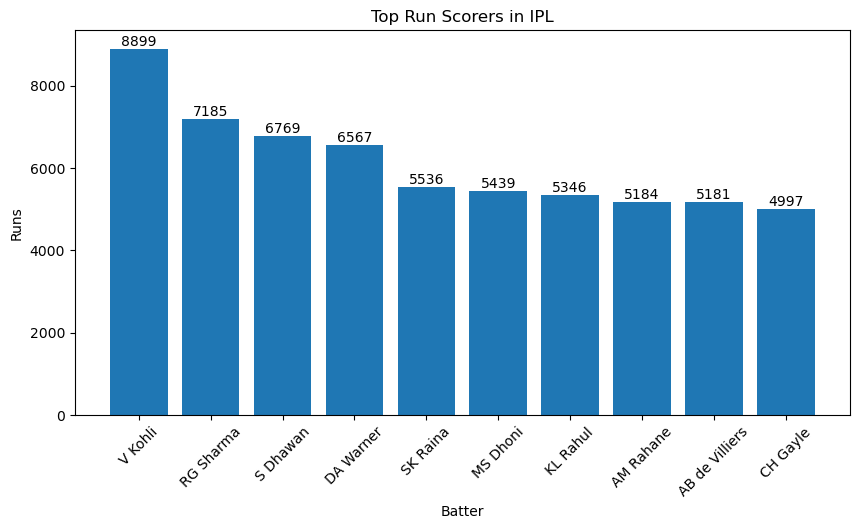

In [68]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    top_runs.index,
    top_runs.values
)

plt.title("Top Run Scorers in IPL")
plt.xlabel("Batter")
plt.ylabel("Runs")

plt.xticks(rotation=45)

plt.bar_label(bars)

plt.show()

Players such as Virat Kohli, Rohit Sharma, and Shikhar Dhawan have consistently accumulated runs across multiple seasons, making them dependable batting assets.

## Batter Analysis 2: Strike Rate

Runs alone are not enough.

A batter scoring 500 runs at SR 150 is often more valuable in T20 than one scoring 500 at SR 120.

In [69]:
batter_stats = (
    ipl_dataset.groupby('batter')
    .agg({
        'runs_batter':'sum',
        'balls_faced':'sum'
    })
)

batter_stats = batter_stats[
    batter_stats['balls_faced'] >= 500
]

batter_stats['Strike_Rate'] = (
    batter_stats['runs_batter']
    /
    batter_stats['balls_faced']
) * 100

top_sr = (
    batter_stats['Strike_Rate']
    .sort_values(ascending=False)
    .head(10)
)

top_sr

batter
TH David           178.597122
PD Salt            174.963397
AD Russell         174.098361
TM Head            168.127490
SP Narine          166.605505
Abhishek Sharma    165.672913
H Klaasen          165.597668
N Pooran           165.134371
RM Patidar         161.771845
T Stubbs           159.844055
Name: Strike_Rate, dtype: float64

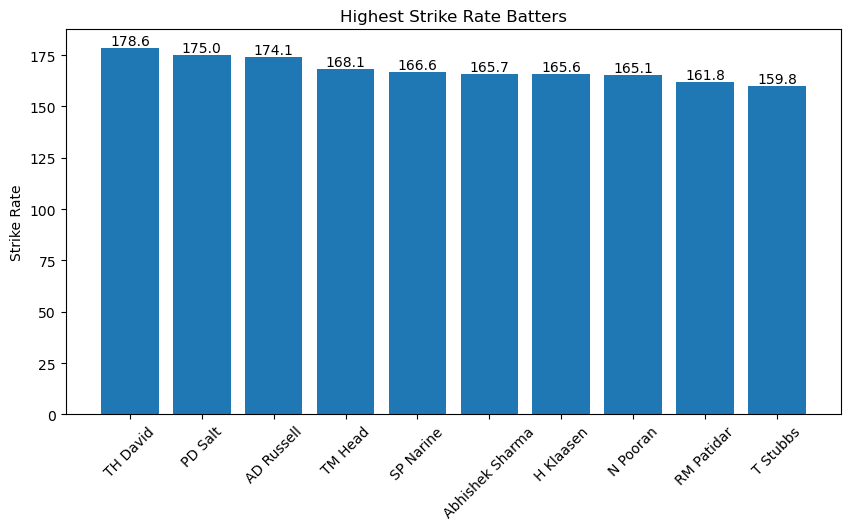

In [70]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    top_sr.index,
    top_sr.values
)

plt.title("Highest Strike Rate Batters")
plt.ylabel("Strike Rate")

plt.xticks(rotation=45)

plt.bar_label(bars, fmt='%.1f')

plt.show()

High strike-rate batters increase scoring efficiency and can significantly influence match outcomes.

## Batter Analysis 3: Player of the Match Awards


In [71]:
potm = (
    matches['player_of_match']
    .value_counts()
    .head(10)
)

potm

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         21
V Kohli           19
MS Dhoni          18
DA Warner         18
SP Narine         17
AD Russell        16
SR Watson         16
RA Jadeja         16
Name: count, dtype: int64

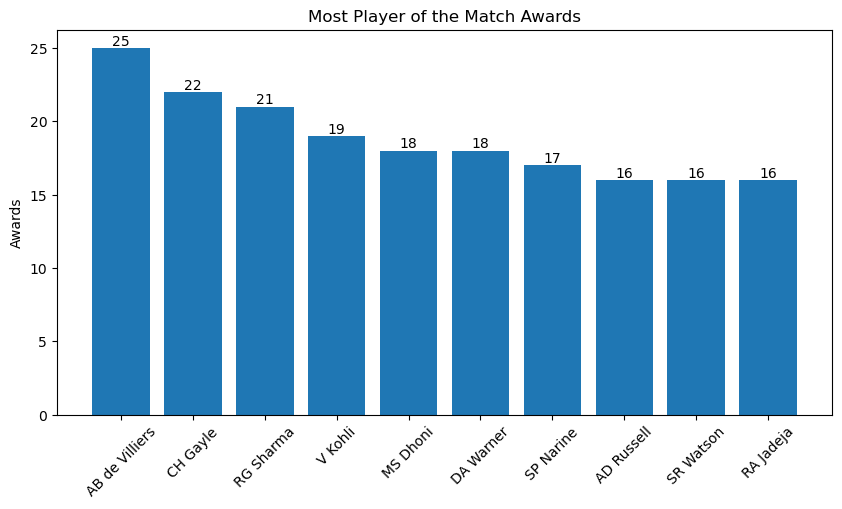

In [72]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    potm.index,
    potm.values
)

plt.title("Most Player of the Match Awards")
plt.ylabel("Awards")

plt.xticks(rotation=45)

plt.bar_label(bars)

plt.show()

Player of the Match awards indicate a batter's ability to influence match outcomes rather than simply accumulate runs.

## Batter Analysis 4: Death Over Specialists

Auction teams love finishers.

In [73]:
death_overs = ipl_dataset[
    ipl_dataset['over'] >= 16
]

death_runs = (
    death_overs.groupby('batter')['runs_batter']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

death_runs

batter
MS Dhoni          2936
KA Pollard        1708
KD Karthik        1565
RA Jadeja         1542
AB de Villiers    1421
HH Pandya         1260
RG Sharma         1176
AD Russell        1134
V Kohli           1121
DA Miller         1100
Name: runs_batter, dtype: int64

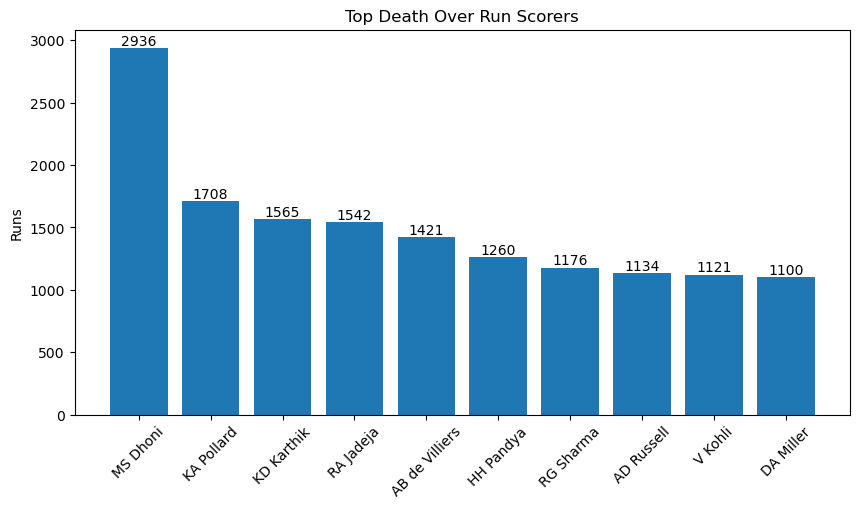

In [74]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    death_runs.index,
    death_runs.values
)

plt.title("Top Death Over Run Scorers")
plt.ylabel("Runs")

plt.xticks(rotation=45)

plt.bar_label(bars)

plt.show()

Players who score heavily in death overs provide exceptional value because they perform during the most impactful phase of a T20 innings.

## Batter Analysis 5: Consistency

How many seasons has a batter played?


In [75]:
batter_seasons = (
    ipl_dataset.groupby('batter')['season']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

batter_seasons

batter
RG Sharma     19
V Kohli       19
MK Pandey     18
RA Jadeja     18
AM Rahane     18
MS Dhoni      18
S Dhawan      17
KD Karthik    17
WP Saha       17
R Ashwin      16
Name: season, dtype: int64

Longevity is an indicator of reliability and adaptability across changing teams, venues, and conditions.

## Batter Reliability Index (BRI)


In [76]:
#Step 1: Create Total Runs Data
runs = (
    ipl_dataset.groupby('batter')['runs_batter']
    .sum()
)

In [77]:
#Step 2: Create Strike Rate Data
strike_rate = (
    ipl_dataset.groupby('batter')
    .agg({
        'runs_batter':'sum',
        'balls_faced':'sum'
    })
)

strike_rate = strike_rate[
    strike_rate['balls_faced'] >= 500
]

strike_rate['Strike_Rate'] = (
    strike_rate['runs_batter']
    /
    strike_rate['balls_faced']
) * 100

strike_rate = strike_rate['Strike_Rate']

In [78]:
#Step 3: POTM Count
potm_count = (
    matches['player_of_match']
    .value_counts()
)

In [79]:
#Step 4: Death Over Runs
death_runs = (
    ipl_dataset[
        ipl_dataset['over'] >= 16
    ]
    .groupby('batter')['runs_batter']
    .sum()
)

In [80]:
#Step 5: Seasons Played
seasons = (
    ipl_dataset.groupby('batter')['season']
    .nunique()
)

In [81]:
#Combine Everything
bri = pd.DataFrame({
    'Runs': runs,
    'Strike_Rate': strike_rate,
    'POTM': potm_count,
    'Death_Runs': death_runs,
    'Seasons': seasons
})

In [82]:
#Fill Missing Values
#Some players won't have POTM awards.
bri = bri.fillna(0)

In [83]:
#Normalize Scores
bri['Runs_Norm'] = (
    bri['Runs']
    /
    bri['Runs'].max()
)

bri['SR_Norm'] = (
    bri['Strike_Rate']
    /
    bri['Strike_Rate'].max()
)

bri['POTM_Norm'] = (
    bri['POTM']
    /
    bri['POTM'].max()
)

bri['Death_Norm'] = (
    bri['Death_Runs']
    /
    bri['Death_Runs'].max()
)

bri['Season_Norm'] = (
    bri['Seasons']
    /
    bri['Seasons'].max()
)